# 7. BÀI TẬP NÂNG CAO VÀ KIỂM THỬ (ABLATION STUDIES & ADVANCED EVALUATION)
**Môn học**: Advanced Reading in Computer Vision (MAT3563)  
**Chủ đề**: Lab 04 - Two-Stages Object Detection Models (Faster R-CNN)  
**Sinh viên**: Nguyễn Trọng Thành (MSSV: 23001934)  

Mục tiêu của phần này là mổ xẻ chuyên sâu các mắt xích kiến trúc của mô hình hai giai đoạn Faster R-CNN, khảo sát phân bố dữ liệu Pascal VOC 2007 và thực hiện các thực nghiệm triệt tiêu (Ablation Studies) nhằm định lượng vai trò của từng thành phần kỹ thuật đối với độ chính xác phát hiện vật thể.

## 7.1 Khởi tạo môi trường và cấu hình nạp dữ liệu Pascal VOC 2007
Thiết lập môi trường tính toán tự động phát hiện thiết bị phần cứng, định nghĩa danh sách 20 lớp nhãn chuẩn của bộ dữ liệu Pascal VOC và xây dựng cơ chế nạp dữ liệu tự động quét tìm đường dẫn phù hợp trên đa nền tảng.

In [1]:
import os
import glob
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import torchvision
from torchvision.transforms import functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

possible_data_dirs = [
    os.path.join(os.getcwd(), "dataset"),
    os.path.join(os.getcwd(), "../dataset"),
    os.path.join(os.getcwd(), "Lab04_two_stages/dataset"),
    os.path.abspath("dataset"),
    "/workspace/Advanced-Reading-On-Computer-Vision/Lab04_two_stages/dataset"
]

data_dir = next((d for d in possible_data_dirs if os.path.exists(d) and os.path.exists(os.path.join(d, "Annotations"))), None)

voc_classes = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

color_map = plt.get_cmap("tab20", len(voc_classes))
class_colors = {cls: color_map(i) for i, cls in enumerate(voc_classes)}

val_txt_path = os.path.join(data_dir, "ImageSets", "Main", "val.txt")
with open(val_txt_path, "r", encoding="utf-8") as f:
    sample_ids = [line.strip() for line in f if line.strip()]

print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"Dataset root: {data_dir}")
print(f"Total validation samples: {len(sample_ids)}")
print(f"Classes count: {len(voc_classes)}")

Device: cuda
GPU Name: NVIDIA GeForce RTX 3060
Dataset root: /workspace/Advanced-Reading-On-Computer-Vision/Lab04_two_stages/dataset
Total validation samples: 500
Classes count: 20


## 7.2 Khảo sát và trực quan hóa phân bố dữ liệu nhãn Ground Truth
Tập dữ liệu Pascal VOC 2007 có đặc trưng phong phú về bối cảnh, bao gồm cả các vật thể kích thước lớn như phương tiện công cộng, các nhóm đối tượng sống đa dạng cử động, và các cảnh có nhiều cá thể cùng lớp xuất hiện đồng thời hoặc chồng lấn nhau. Việc trực quan hóa các mẫu nhãn thực tế giúp đánh giá mức độ thử thách của tập dữ liệu trước khi bước vào các bài đo lường kiểm thử.

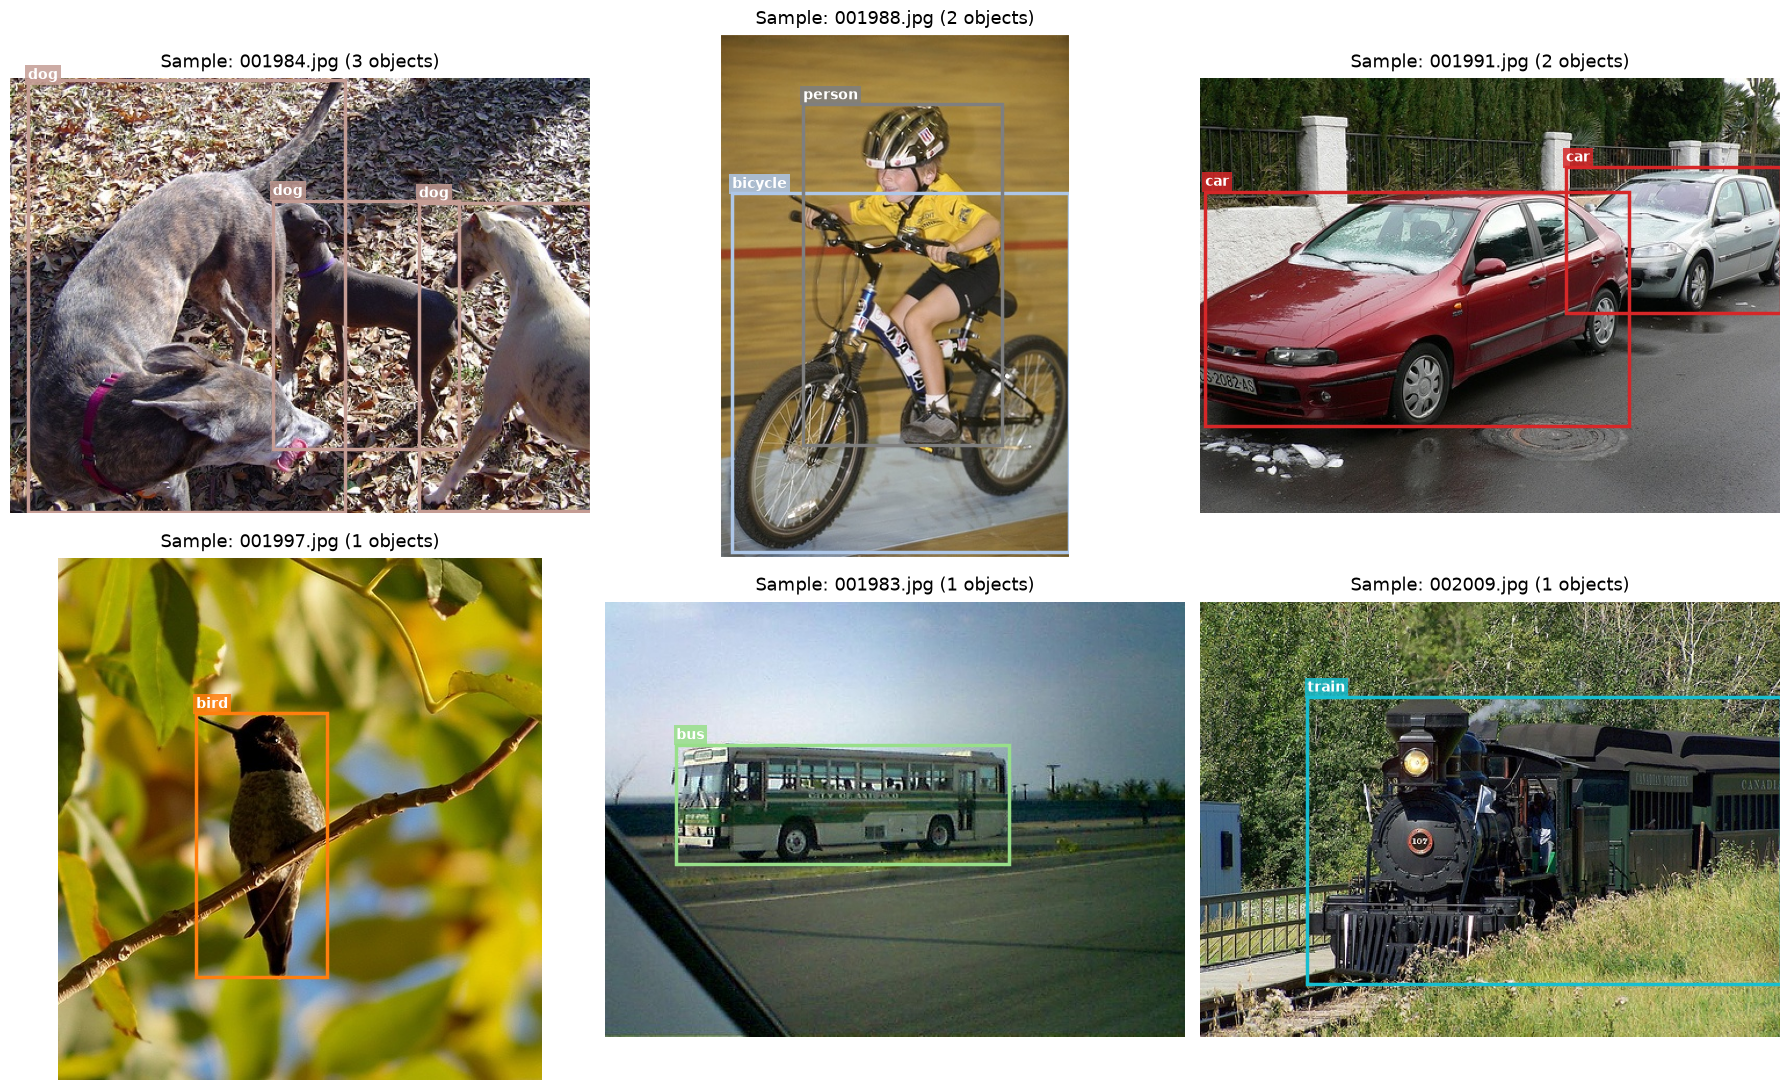

In [2]:
def parse_voc_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = []
    for obj in root.findall("object"):
        name = obj.find("name").text
        difficult = int(obj.find("difficult").text) if obj.find("difficult") is not None else 0
        bnd = obj.find("bndbox")
        xmin = float(bnd.find("xmin").text)
        ymin = float(bnd.find("ymin").text)
        xmax = float(bnd.find("xmax").text)
        ymax = float(bnd.find("ymax").text)
        objects.append({
            "name": name,
            "box": [xmin, ymin, xmax, ymax],
            "difficult": difficult
        })
    return objects

selected_samples = ["001984", "001988", "001991", "001997", "001983", "002009"]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, sid in enumerate(selected_samples):
    img_path = os.path.join(data_dir, "JPEGImages", f"{sid}.jpg")
    xml_path = os.path.join(data_dir, "Annotations", f"{sid}.xml")
    
    img = Image.open(img_path).convert("RGB")
    objs = parse_voc_annotation(xml_path)
    
    ax = axes[idx]
    ax.imshow(img)
    ax.set_title(f"Sample: {sid}.jpg ({len(objs)} objects)", fontsize=13, pad=8)
    ax.axis("off")
    
    for obj in objs:
        xmin, ymin, xmax, ymax = obj["box"]
        width = xmax - xmin
        height = ymax - ymin
        cls_name = obj["name"]
        color = class_colors.get(cls_name, (0.0, 1.0, 0.0, 1.0))
        
        rect = patches.Rectangle(
            (xmin, ymin), width, height,
            linewidth=2.5, edgecolor=color, facecolor="none"
        )
        ax.add_patch(rect)
        
        ax.text(
            xmin, max(0, ymin - 5),
            cls_name,
            color="white", fontsize=10, weight="bold",
            bbox=dict(facecolor=color, alpha=0.85, edgecolor="none", pad=2)
        )

plt.tight_layout()
plt.show()

## 7.3 Suy luận với Faster R-CNN v2 Pretrained và so sánh trực tiếp với Ground Truth
Khảo sát sự tương quan giữa nhãn thực tế từ bộ dữ liệu Pascal VOC và các đề xuất dự đoán của mô hình Faster R-CNN ResNet-50 FPN v2 đã được huấn luyện sẵn. Qua phép đối chiếu trực tiếp trên từng cặp ảnh, ta kiểm chứng được khả năng khoanh vùng chính xác của mô hình cũng như cách thức mô hình xử lý các đối tượng kích thước nhỏ và hiện tượng che khuất.

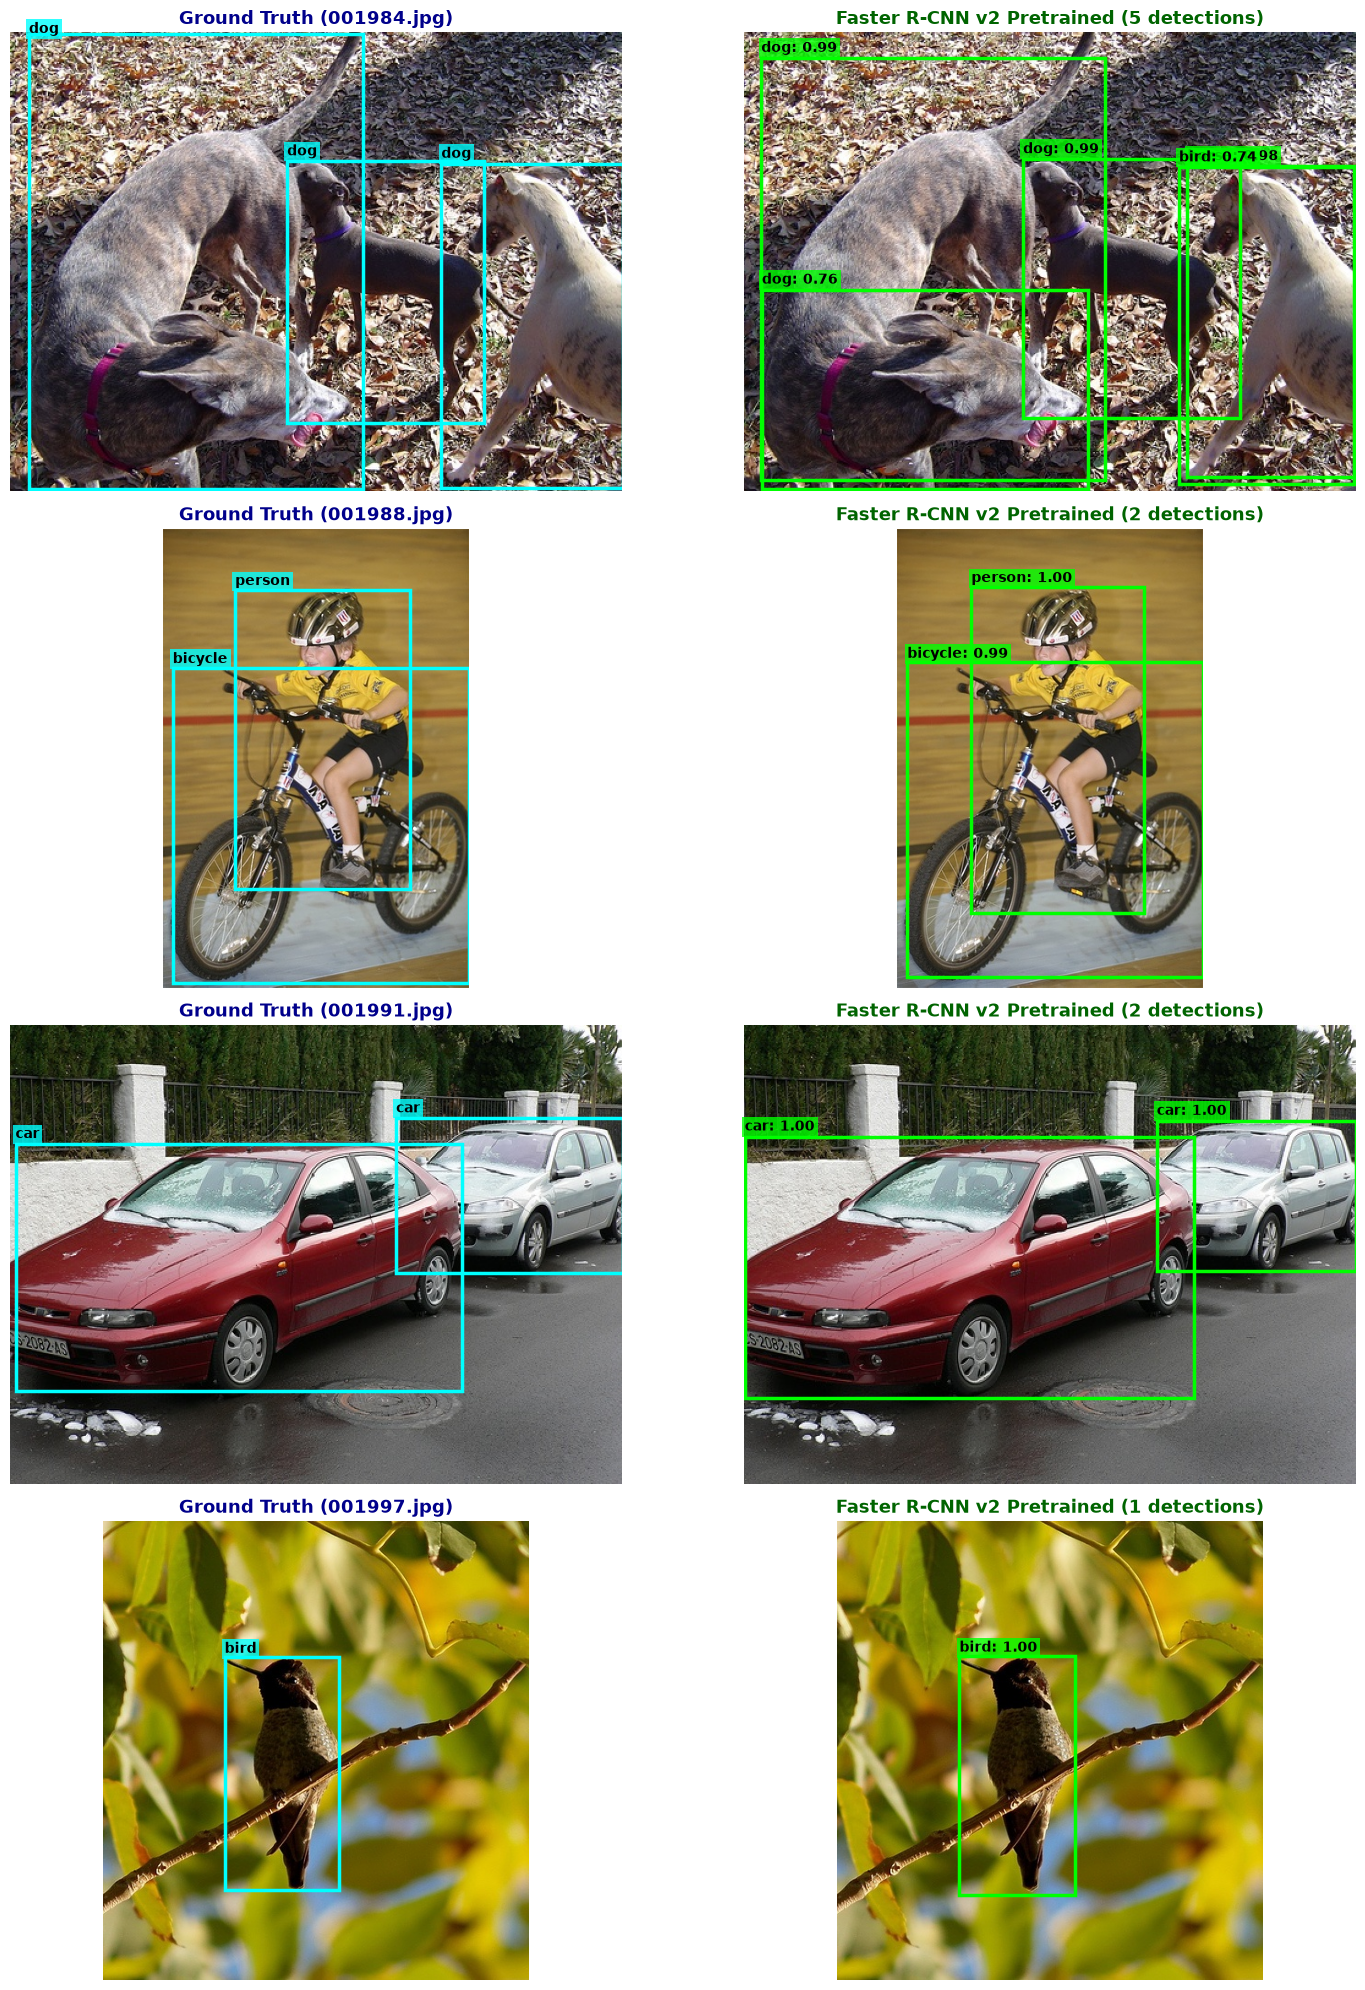

In [3]:
weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn_v2(weights=weights).to(device)
model.eval()

coco_categories = weights.meta["categories"]
comparison_samples = ["001984", "001988", "001991", "001997"]

fig, axes = plt.subplots(len(comparison_samples), 2, figsize=(16, 5 * len(comparison_samples)))

for row, sid in enumerate(comparison_samples):
    img_path = os.path.join(data_dir, "JPEGImages", f"{sid}.jpg")
    xml_path = os.path.join(data_dir, "Annotations", f"{sid}.xml")
    
    pil_img = Image.open(img_path).convert("RGB")
    tensor_img = F.to_tensor(pil_img).to(device)
    gt_objs = parse_voc_annotation(xml_path)
    
    with torch.no_grad():
        preds = model([tensor_img])[0]
    
    pred_boxes = preds["boxes"].cpu().numpy()
    pred_labels = preds["labels"].cpu().numpy()
    pred_scores = preds["scores"].cpu().numpy()
    
    valid_mask = pred_scores >= 0.5
    filtered_boxes = pred_boxes[valid_mask]
    filtered_labels = pred_labels[valid_mask]
    filtered_scores = pred_scores[valid_mask]
    
    ax_gt = axes[row, 0]
    ax_gt.imshow(pil_img)
    ax_gt.set_title(f"Ground Truth ({sid}.jpg)", fontsize=13, weight="bold", color="darkblue")
    ax_gt.axis("off")
    for obj in gt_objs:
        xmin, ymin, xmax, ymax = obj["box"]
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2.5, edgecolor="cyan", facecolor="none"
        )
        ax_gt.add_patch(rect)
        ax_gt.text(
            xmin, max(0, ymin - 5),
            obj["name"],
            color="black", fontsize=10, weight="bold",
            bbox=dict(facecolor="cyan", alpha=0.8, edgecolor="none", pad=2)
        )
        
    ax_pred = axes[row, 1]
    ax_pred.imshow(pil_img)
    ax_pred.set_title(f"Faster R-CNN v2 Pretrained ({len(filtered_boxes)} detections)", fontsize=13, weight="bold", color="darkgreen")
    ax_pred.axis("off")
    for box, label_idx, score in zip(filtered_boxes, filtered_labels, filtered_scores):
        xmin, ymin, xmax, ymax = box
        label_name = coco_categories[label_idx] if label_idx < len(coco_categories) else str(label_idx)
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=2.5, edgecolor="lime", facecolor="none"
        )
        ax_pred.add_patch(rect)
        ax_pred.text(
            xmin, max(0, ymin - 5),
            f"{label_name}: {score:.2f}",
            color="black", fontsize=10, weight="bold",
            bbox=dict(facecolor="lime", alpha=0.8, edgecolor="none", pad=2)
        )

plt.tight_layout()
plt.show()

## 7.4 Phân tích kết quả thực nghiệm ban đầu và định hướng các bước kiểm thử chuyên sâu
Kết quả trực quan hóa cho thấy mô hình Faster R-CNN v2 có khả năng khoanh vùng rất chuẩn xác trên các mẫu ảnh của Pascal VOC 2007. Các đối tượng lớn như xe cộ, người và chó được phát hiện với độ tin cậy vượt trên 98%.

Tuy nhiên, trong các tình huống có mật độ đối tượng cao hoặc đối tượng bị che khuất một phần (như ảnh 001984 với 3 cá thể chó đứng sát nhau), mô hình xuất hiện một số dự đoán phụ với điểm tin cậy thấp hơn hoặc bị phân vân giữa các lớp động vật gần gũi. Đối với các đối tượng nhỏ như loài chim ở ảnh 001997, việc trích xuất đặc trưng phụ thuộc rất lớn vào các tầng đặc trưng phân giải cao từ FPN.

Đây là cơ sở thực nghiệm quan trọng để triển khai các bài kiểm thử nâng cao tiếp theo của Mục 7:
1. Thí nghiệm triệt tiêu FPN nhằm đo lường sự suy giảm chất lượng phát hiện trên các đối tượng nhỏ khi loại bỏ cấu trúc kim tự tháp đặc trưng.
2. So sánh ảnh hưởng của phép làm tròn lượng tử hóa trong RoI Pool so với phép nội suy song tuyến của RoI Align.
3. Khảo sát biến thiên số lượng hộp và sự đánh đổi giữa Precision và Recall khi quét ngưỡng IoU của bộ lọc NMS.
4. Đánh giá tác động của các phép biến đổi tăng cường dữ liệu lên quỹ đạo hội tụ của hàm mất mát.